## Step 1: Install Dependencies

In [2]:
!pip install wordcloud -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 114.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

## Step 2: load_texts()

In [3]:
import re
import requests

URLS = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",    # Alice in Wonderland
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",    # Through the Looking-Glass
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt" # A Tangled Tale
]

BOOK_TITLES = [
    "Alice's Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale"
]

def load_texts(urls):
  corpus = []
  for url in urls:
    response = requests.get(url)
    raw = response.text
    cleaned = re.sub(r"[^a-zA-Z\s']", " ", raw)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    corpus.append(cleaned)
  return corpus

corpus = load_texts(URLS)
print(f"Loaded {len(corpus)} books")


Loaded 3 books


## Step 3: Preview and trim Gutenberg boilerplate

In [4]:
# preview first 200 chars
for title, text in zip(BOOK_TITLES, corpus):
  print(f"book {title}")
  print(text[:200])


book Alice's Adventures in Wonderland
The Project Gutenberg eBook of Alice's Adventures in Wonderland This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restri
book Through the Looking-Glass
The Project Gutenberg eBook of Through the Looking Glass This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions 
book A Tangled Tale
The Project Gutenberg eBook of A Tangled Tale This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever 


In [5]:
# trim headers and footers
def trim_gutenberg(text):
  start = text.find("*** START")
  end = text.find("*** END")
  if start != -1:
    text = text[text.find("\n", start) + 1:]
  if end != -1:
    text = text[:end]
  return text.strip()

corpus = [trim_gutenberg(text) for text in corpus]
print("Gutenberg headers and footers removed")

Gutenberg headers and footers removed


## Step 4: Tokenization

In [6]:
from nltk.tokenize import word_tokenize

tokenized_corpus = []
for title, text in zip(BOOK_TITLES, corpus):
  tokens = word_tokenize(text.lower())
  tokenized_corpus.append(tokens)
  print(f"Books {title}")
  print(f"Total tokens: {len(tokens):,}")
  print(f"First 150 tokens:\n{tokens[:150]}\n")

Books Alice's Adventures in Wonderland
Total tokens: 30,487
First 150 tokens:
['the', 'project', 'gutenberg', 'ebook', 'of', 'alice', "'s", 'adventures', 'in', 'wonderland', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', 'you', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 're', 'use', 'it', 'under', 'the', 'terms', 'of', 'the', 'project', 'gutenberg', 'license', 'included', 'with', 'this', 'ebook', 'or', 'online', 'at', 'www', 'gutenberg', 'org', 'if', 'you', 'are', 'not', 'located', 'in', 'the', 'united', 'states', 'you', 'will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located', 'before', 'using', 'this', 'ebook', 'title', 'alice', "'s", 'adventures', 'in', 'wonderland', 'author', 'lewis', 'carroll', 'release', 'date', 'june', 'ebook', 'most', '

## Step 5: Remove stopwords

In [7]:
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))
check_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']

filtered_corpus = []
for title, tokens in zip(BOOK_TITLES, tokenized_corpus):
    filtered = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
    filtered_corpus.append(filtered)
    print(f"Book {title}")
    print(f"  Before: {len(tokens):,}  →  After: {len(filtered):,}")
    for w in check_words:
        print(f"  count('{w}'): {filtered.count(w)}")

Book Alice's Adventures in Wonderland
  Before: 30,487  →  After: 14,010
  count('i'): 0
  count('me'): 0
  count('my'): 0
  count('myself'): 0
  count('we'): 0
  count('our'): 0
  count('ours'): 0
  count('ourselves'): 0
Book Through the Looking-Glass
  Before: 34,148  →  After: 15,809
  count('i'): 0
  count('me'): 0
  count('my'): 0
  count('myself'): 0
  count('we'): 0
  count('our'): 0
  count('ours'): 0
  count('ourselves'): 0
Book A Tangled Tale
  Before: 30,967  →  After: 15,789
  count('i'): 0
  count('me'): 0
  count('my'): 0
  count('myself'): 0
  count('we'): 0
  count('our'): 0
  count('ours'): 0
  count('ourselves'): 0


## Step 6: Stemming

In [10]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed_corpus = []
for title, tokens in zip(BOOK_TITLES, filtered_corpus):
    stemmed = [stemmer.stem(t) for t in tokens]
    stemmed_corpus.append(stemmed)
    print(f"Book {title}")
    print(f" First 50 stemmed tokens: \n{stemmed[:50]}\n")

Book Alice's Adventures in Wonderland
 First 50 stemmed tokens: 
['project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'ebook', 'use', 'anyon', 'anywher', 'unit', 'state', 'part', 'world', 'cost', 'almost', 'restrict', 'whatsoev', 'may', 'copi', 'give', 'away', 'use', 'term', 'project', 'gutenberg', 'licens', 'includ', 'ebook', 'onlin', 'www', 'gutenberg', 'org', 'locat', 'unit', 'state', 'check', 'law', 'countri', 'locat', 'use', 'ebook', 'titl', 'alic', 'adventur', 'wonderland', 'author', 'lewi', 'carrol', 'releas']

Book Through the Looking-Glass
 First 50 stemmed tokens: 
['project', 'gutenberg', 'ebook', 'look', 'glass', 'ebook', 'use', 'anyon', 'anywher', 'unit', 'state', 'part', 'world', 'cost', 'almost', 'restrict', 'whatsoev', 'may', 'copi', 'give', 'away', 'use', 'term', 'project', 'gutenberg', 'licens', 'includ', 'ebook', 'onlin', 'www', 'gutenberg', 'org', 'locat', 'unit', 'state', 'check', 'law', 'countri', 'locat', 'use', 'ebook', 'titl', 'look', 'glass', 'a

## Step 7: spaCy lemmatization

In [13]:
import spacy

nlp = spacy.load("en_core_web_sm")
lemmatized_corpus = []

for title, tokens in zip(BOOK_TITLES, filtered_corpus):
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc if token.is_alpha]
    lemmatized_corpus.append(lemmas)
    print(f"Book {title}")
    print(f"First 50 lemmatized tokens:\n{lemmas[:50]}\n")

Book Alice's Adventures in Wonderland
First 50 lemmatized tokens:
['project', 'gutenberg', 'ebook', 'alice', 'adventure', 'wonderland', 'ebook', 'use', 'anyone', 'anywhere', 'united', 'states', 'part', 'world', 'cost', 'almost', 'restriction', 'whatsoever', 'may', 'copy', 'give', 'away', 'use', 'term', 'project', 'gutenberg', 'license', 'include', 'ebook', 'online', 'www', 'gutenberg', 'org', 'locate', 'united', 'states', 'check', 'law', 'country', 'locate', 'use', 'ebook', 'title', 'alice', 'adventure', 'wonderland', 'author', 'lewis', 'carroll', 'release']

Book Through the Looking-Glass
First 50 lemmatized tokens:
['project', 'gutenberg', 'ebook', 'look', 'glass', 'ebook', 'use', 'anyone', 'anywhere', 'united', 'states', 'part', 'world', 'cost', 'almost', 'restriction', 'whatsoever', 'may', 'copy', 'give', 'away', 'use', 'term', 'project', 'gutenberg', 'license', 'include', 'ebook', 'online', 'www', 'gutenberg', 'org', 'locate', 'united', 'states', 'check', 'law', 'country', 'locate

## Step 8: Compare Stemming vs Lemmatization

In [14]:
examples = ["running", "studies", "better", "mice", "caring", "wonderfully"]
doc = nlp(" ".join(examples))

print(f"{'Word':<15} {'Stemmed':<15} {'Lemmatized'}")
print("-" * 45)
for word, token in zip(examples, doc):
    print(f"{word:<15} {stemmer.stem(word):<15} {token.lemma_}")

Word            Stemmed         Lemmatized
---------------------------------------------
running         run             run
studies         studi           study
better          better          well
mice            mice            mouse
caring          care            care
wonderfully     wonder          wonderfully


## Step 9: POS Tagging

In [15]:
from nltk import pos_tag

for title, tokens in zip(BOOK_TITLES, filtered_corpus):
  tags = pos_tag(tokens[:30])
  print(f"Book {title}")
  print(tags)
  print()

Book Alice's Adventures in Wonderland
[('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('alice', 'NN'), ('adventures', 'NNS'), ('wonderland', 'VBP'), ('ebook', 'NN'), ('use', 'NN'), ('anyone', 'NN'), ('anywhere', 'RB'), ('united', 'JJ'), ('states', 'NNS'), ('parts', 'NNS'), ('world', 'NN'), ('cost', 'NN'), ('almost', 'RB'), ('restrictions', 'NNS'), ('whatsoever', 'VBP'), ('may', 'MD'), ('copy', 'VB'), ('give', 'VB'), ('away', 'RP'), ('use', 'NN'), ('terms', 'NNS'), ('project', 'VBP'), ('gutenberg', 'JJ'), ('license', 'NN'), ('included', 'VBD'), ('ebook', 'CD'), ('online', 'NN')]

Book Through the Looking-Glass
[('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('looking', 'VBG'), ('glass', 'NN'), ('ebook', 'NN'), ('use', 'NN'), ('anyone', 'NN'), ('anywhere', 'RB'), ('united', 'JJ'), ('states', 'NNS'), ('parts', 'NNS'), ('world', 'NN'), ('cost', 'NN'), ('almost', 'RB'), ('restrictions', 'NNS'), ('whatsoever', 'VBP'), ('may', 'MD'), ('copy', 'VB'), ('give', 'VB'), ('away'

## Step 10: NER

In [20]:
from nltk import ne_chunk, pos_tag
from nltk.tokenize import word_tokenize

for title, text in zip(BOOK_TITLES, corpus):
    tokens_original = word_tokenize(text)[:100]
    tags = pos_tag(tokens_original)
    tree = ne_chunk(tags)
    entities = [
        (" ".join(w for w, t in sub.leaves()), sub.label())
        for sub in tree if hasattr(sub, 'label')
    ]
    print(f"Book {title}")
    print(entities[:15])
    print()

Book Alice's Adventures in Wonderland
[('Project Gutenberg', 'ORGANIZATION'), ('Alice', 'GPE'), ('Wonderland', 'GPE'), ('United States', 'GPE'), ('Project Gutenberg License', 'ORGANIZATION'), ('United States', 'GPE'), ('eBook Title Alice', 'ORGANIZATION')]

Book Through the Looking-Glass
[('Project Gutenberg', 'ORGANIZATION'), ('United States', 'GPE'), ('Project Gutenberg License', 'ORGANIZATION'), ('United States', 'GPE'), ('eBook Title', 'ORGANIZATION')]

Book A Tangled Tale
[('Project Gutenberg', 'ORGANIZATION'), ('United States', 'GPE'), ('Project Gutenberg License', 'ORGANIZATION'), ('United States', 'GPE'), ('eBook Title', 'ORGANIZATION'), ('Lewis Carroll', 'PERSON')]



## Analysis 1: Word Clouds

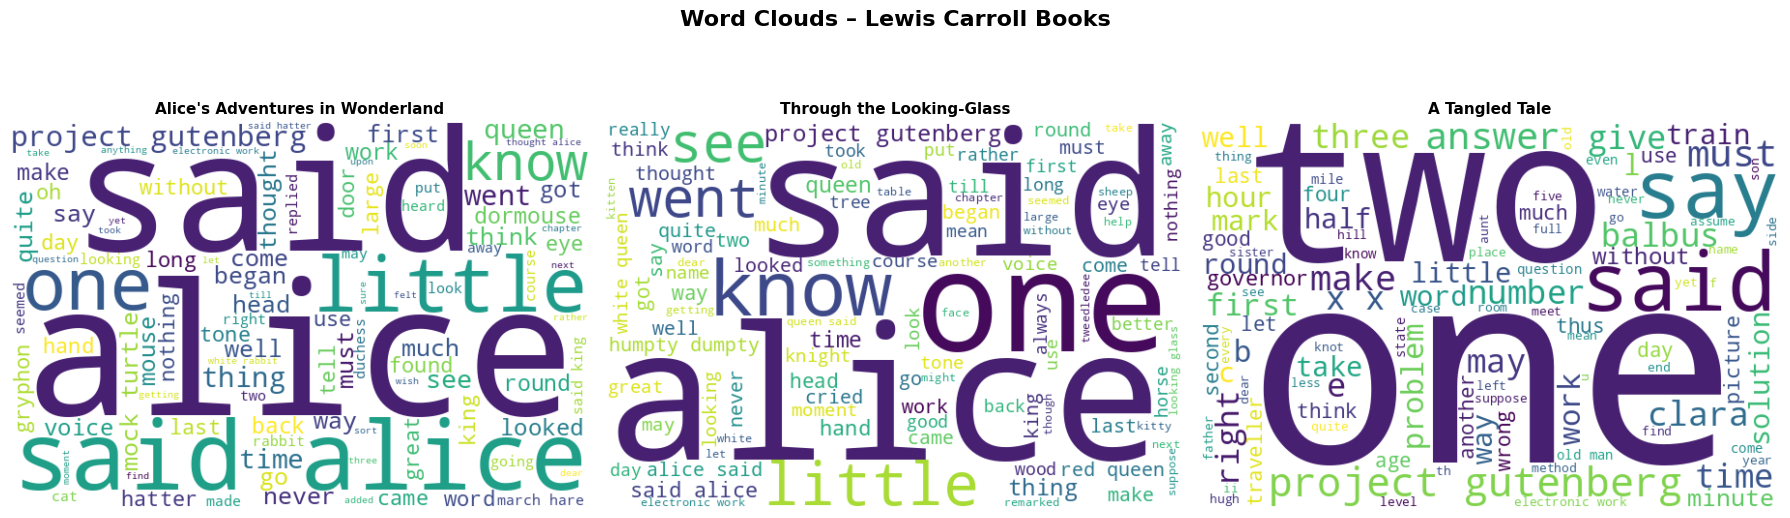

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Word Clouds – Lewis Carroll Books", fontsize=16, fontweight='bold')

for i, (title, tokens) in enumerate(zip(BOOK_TITLES, filtered_corpus)):
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        max_words=100,
        colormap='viridis',
        random_state=42
    ).generate(" ".join(tokens))
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Analysis 2: BoW matrix

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

docs = [" ".join(t) for t in lemmatized_corpus]
vec  = CountVectorizer()
bow  = vec.fit_transform(docs)
voc  = vec.get_feature_names_out()

print(f"BoW matrix shape: {bow.shape}")
print("→ rows=documents, cols=unique words, values=word count\n")

# Print a sample of the matrix
print(f"{'Doc':>4}  {'Index':>6}  {'Word':>20}  {'Count':>6}")
print("-" * 42)
for doc_i in range(3):
    arr = np.array(bow[doc_i].todense()).flatten()
    top_idx = arr.argsort()[-5:][::-1]
    for idx in top_idx:
        print(f"{doc_i:>4}  {idx:>6}  {voc[idx]:>20}  {arr[idx]:>6}")

BoW matrix shape: (3, 4951)
→ rows=documents, cols=unique words, values=word count

 Doc   Index                  Word   Count
------------------------------------------
   0    3730                   say     530
   0     121                 alice     403
   0    1869                    go     172
   0    2538                little     129
   0    2404                  know     108
   1    3730                   say     544
   1     121                 alice     468
   1    3426                 queen     201
   1    1869                    go     179
   1    2567                  look     157
   2    3730                   say     233
   2    3008                   one     214
   2    4528                   two     108
   2     177                answer     101
   2    2616                  make      99


## Analysis 3: BoW pie charts

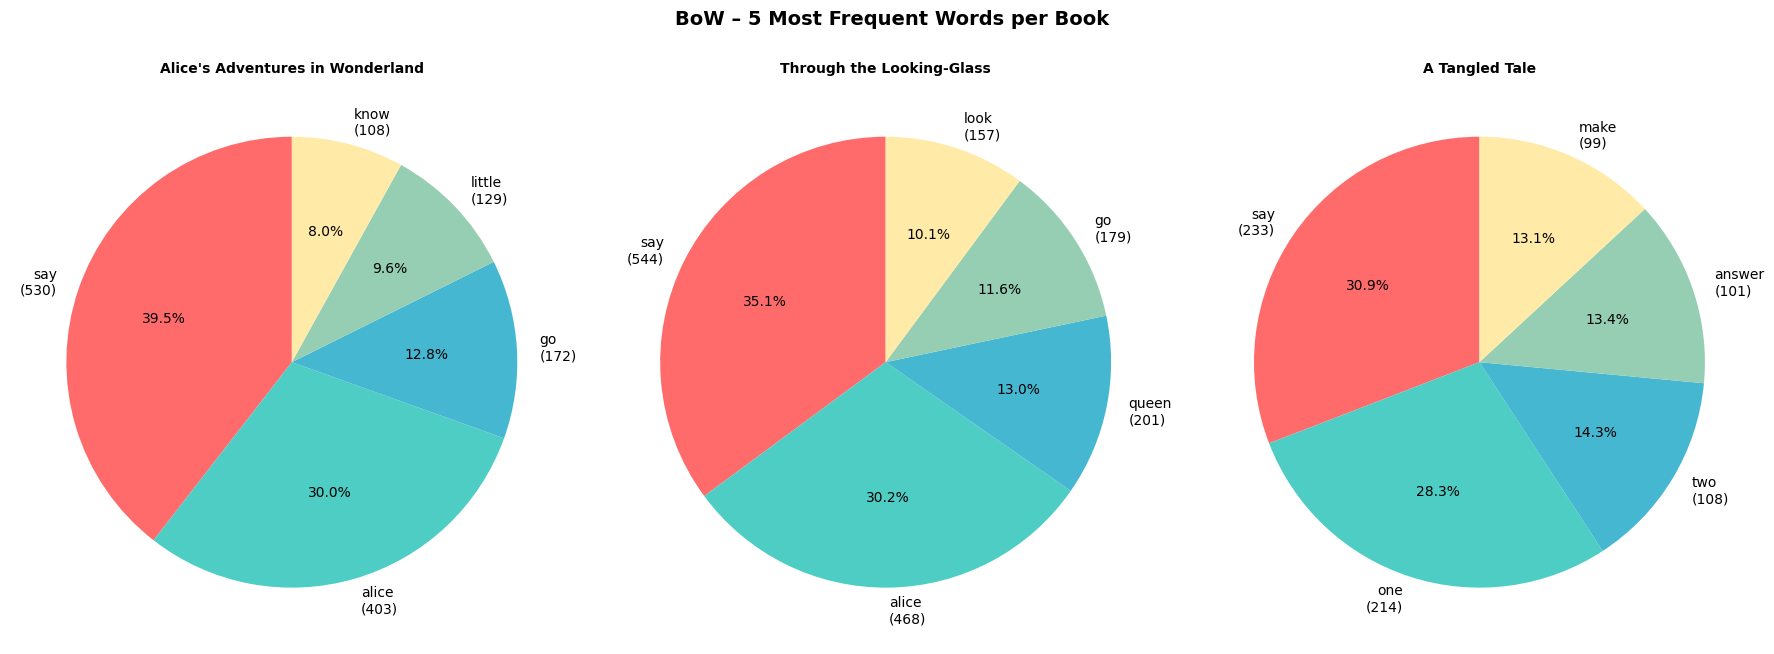

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("BoW – 5 Most Frequent Words per Book", fontsize=14, fontweight='bold')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for i, (title, ax) in enumerate(zip(BOOK_TITLES, axes)):
    arr    = np.array(bow[i].todense()).flatten()
    top5   = arr.argsort()[-5:][::-1]
    words  = [voc[j] for j in top5]
    freqs  = [arr[j] for j in top5]
    labels = [f"{w}\n({f})" for w, f in zip(words, freqs)]
    ax.pie(freqs, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Analysis 4: Are the BoW word informative?

The top BoW words will be things like "alice", "said", "little" — expected but not insightful. "alice" appears in nearly every sentence of both Alice books, so a high count just confirms the protagonist's name, not the book's themes. This is the fundamental problem with raw frequency counts, and exactly what TF-IDF is designed to fix.

## TF-IDF step 1: Fit the vectorizer

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=1, max_df=2)
tm = tfidf.fit_transform(docs)
tv = tfidf.get_feature_names_out()

print(f"TF-IDF matrix shape: {tm.shape}")
print()

for i, title in enumerate(BOOK_TITLES):
  arr = np.array(tm[i].todense()).flatten()
  top5  = arr.argsort()[-5:][::-1]
  words = [(tv[j], round(float(arr[j]), 4)) for j in top5]
  print(f"📖 {title}:")
  for w, s in words:
    print(f"   {w:<25} score: {s}")
  print()

TF-IDF matrix shape: (3, 3800)

📖 Alice's Adventures in Wonderland:
   gryphon                   score: 0.3338
   rabbit                    score: 0.3278
   turtle                    score: 0.2862
   mock                      score: 0.2631
   hatter                    score: 0.2631

📖 Through the Looking-Glass:
   humpty                    score: 0.3538
   dumpty                    score: 0.3538
   knight                    score: 0.2931
   tweedledum                score: 0.2337
   tweedledee                score: 0.1832

📖 A Tangled Tale:
   balbus                    score: 0.3307
   clara                     score: 0.2934
   train                     score: 0.1877
   solution                  score: 0.177
   governor                  score: 0.1537



## TF-IDF Step 2: Pie charts

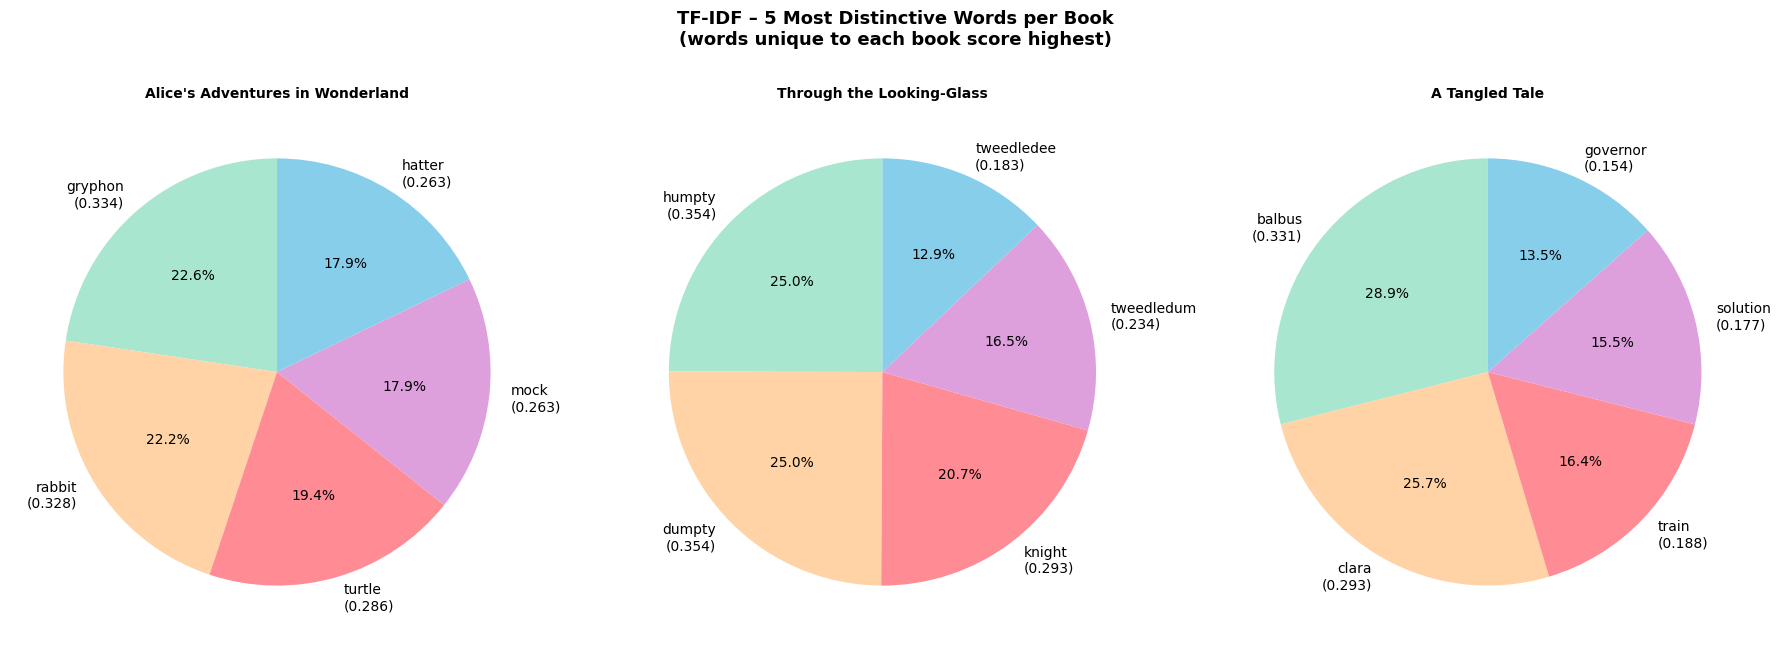

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    "TF-IDF – 5 Most Distinctive Words per Book\n(words unique to each book score highest)",
    fontsize=13, fontweight='bold'
)
colors2 = ['#A8E6CF', '#FFD3A5', '#FF8B94', '#DDA0DD', '#87CEEB']

for i, (title, ax) in enumerate(zip(BOOK_TITLES, axes)):
    arr    = np.array(tm[i].todense()).flatten()
    top5   = arr.argsort()[-5:][::-1]
    words  = [tv[j] for j in top5]
    scores = [float(arr[j]) for j in top5]
    labels = [f"{w}\n({s:.3f})" for w, s in zip(words, scores)]
    ax.pie(scores, labels=labels, colors=colors2, autopct='%1.1f%%', startangle=90)
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()